In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Single Variable Calculus

In that section, we met the basic elements of differential calculus. This section goes deeper, building the one-variable theory we actually lean on in deep learning: the derivative as a *local linear model*, the rules that compute it mechanically, and three things that local model is *for*: it hands us gradient descent, it explains curvature through the second derivative and Taylor series, and it tells us what to do at the corners of a function like $\mathrm{ReLU}$ where the model breaks down.

## The Derivative

Differential calculus is, at heart, the study of how a function behaves under a *small change* of its input. To see why this is the question deep learning cares about, picture a neural network whose weights are stacked into one long vector $\mathbf{w} = (w_1, \ldots, w_n)$, and write $L(\mathbf{w})$ for its loss on a training set. This $L$ is hopelessly complicated (it encodes the performance of *every* model of the given architecture), so we cannot simply read off the minimizing $\mathbf{w}$. Instead we initialize $\mathbf{w}$ randomly and repeatedly take a small step against the gradient,

$$
\mathbf{w} \leftarrow \mathbf{w} - \eta\, \nabla L(\mathbf{w}),
$$

where $\nabla L(\mathbf{w})$ (the *gradient*, defined in that section) collects the derivative of $L$ with respect to each weight, and $\eta > 0$ is a small *step size*. Everything in this section is in service of one question: *which way is downhill, and by how much?* We answer it first for a single weight: freeze every weight but one, call the free one $x \in \mathbb{R}$, and study the one-variable slice $f(x) = L(w_1, \ldots, x, \ldots, w_n)$.

### Zooming In: Every Smooth Curve Looks Like a Line

Take a point $x$ and nudge it to $x + \epsilon$ for a tiny $\epsilon$ (if it helps, picture $\epsilon = 10^{-7}$). Plot any familiar function, say $f(x) = \sin(x^x)$ on $[0,3]$, and it wiggles in a complicated way; but zoom in on a small window around a point and the wiggles flatten out, until on a small enough scale the graph is indistinguishable from a *straight line*. the figure shows this for three successively smaller windows.

![The same smooth curve viewed over shrinking $x$-ranges: as we zoom in around the base point it flattens onto its tangent line.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-zoom-sequence.svg)

This is the observation single-variable calculus is built on: *locally, a smooth function is a line.* So as we shift $x$ by a little, $f(x)$ shifts by a little too, and the only thing left to pin down is the proportionality: is the output change half the input change? Twice? That ratio is the slope of the line we zoomed in on.

### The Difference Quotient and the Derivative

To measure that slope we compare the change in output to the change in input,

$$
\frac{f(x+\epsilon) - f(x)}{(x+\epsilon) - x} = \frac{f(x+\epsilon) - f(x)}{\epsilon},
$$

the slope of the *secant* line through $(x, f(x))$ and $(x+\epsilon, f(x+\epsilon))$. As $\epsilon$ shrinks, the second point slides toward the first and the secant rotates into the tangent line we saw under the microscope; the figure shows this rotation. We can watch the slope settle down in code. We use the following imports throughout the section.

![The difference quotient is the slope of the secant through $(x, f(x))$ and $(x+\epsilon, f(x+\epsilon))$; as $\epsilon \to 0$ the second point slides toward the first and the secant rotates into the tangent line, whose slope is the derivative $f'(x)$.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-secant-to-tangent.svg)

In [1]:
%matplotlib inline
import math
import numpy as onp
from d2l import torch as d2l
import torch

Take $f(x) = x^2 + 1701(x-4)^3$ and evaluate the difference quotient at $x = 4$ for shrinking $\epsilon$.

In [2]:
# Define our function
def f(x):
    return x**2 + 1701*(x-4)**3

# Slope of the secant through x=4, for shrinking epsilon
for epsilon in [0.1, 0.001, 0.0001, 0.00001]:
    print(f'epsilon = {epsilon:.5f} -> {(f(4+epsilon) - f(4)) / epsilon:.5f}')

epsilon = 0.10000 -> 25.11000
epsilon = 0.00100 -> 8.00270
epsilon = 0.00010 -> 8.00012
epsilon = 0.00001 -> 8.00001


The numbers march toward $8$, and the smaller $\epsilon$ gets the closer they sit. The cubic is there to make the convergence *visible*: expanding $f(4+\epsilon) - f(4) = 8\epsilon + \epsilon^2 + 1701\,\epsilon^3$, the difference quotient is $8 + \epsilon + 1701\,\epsilon^2$, so the cubic contributes a $1701\,\epsilon^2$ error: a hefty $17$ at $\epsilon = 0.1$ (which is why the top row sits so far off) but a negligible $1.7\times10^{-7}$ once $\epsilon$ reaches $10^{-5}$. So the slope we are after at $x = 4$ is $8$, written

$$
\lim_{\epsilon \rightarrow 0}\frac{f(4+\epsilon) - f(4)}{\epsilon} = 8.
$$

The table only ever creeps toward that limit; the framework's automatic differentiation (that section) applies exact differentiation rules instead, evaluated in floating-point arithmetic, so there is no $\epsilon$ and no truncation error (only rounding remains). Asking the framework for the slope of the very same $f$ at $x = 4$ returns $8$ on the nose. This is the machinery the differentiation rules below formalize, and that we rebuild from scratch in that section.

In [3]:
# Autograd computes the limit exactly: f'(4) = 8
x = torch.tensor(4.0, requires_grad=True)
f(x).backward()
print(f"autograd: f'(4) = {x.grad.item():.1f}")

autograd: f'(4) = 8.0


This very computation, the *method of finite differences*, measures the effect of a weight on the loss directly: perturb the weight, re-run the network, watch the loss move. It costs an extra evaluation of $L$ per weight (or two, for the centered differences that halve the truncation error), so with even a few thousand parameters it is thousands of forward passes for a single gradient. The *backpropagation algorithm* popularized in 1986 by @Rumelhart.Hinton.Williams.ea.1988 removes that bottleneck: it delivers the effect of *all* weights at once, at a small constant multiple of the cost of one forward pass, the *cheap-gradient principle* [@Griewank.Walther.2008]. Backpropagation is the chain rule (below) run in reverse over the network.

The slope is itself a function of $x$, so we name it. The **derivative** of $f$ is

$$\frac{df}{dx}(x) = \lim_{\epsilon \rightarrow 0}\frac{f(x+\epsilon) - f(x)}{\epsilon},$$

when the limit exists. (When it fails to, as at the corner of $\mathrm{ReLU}$, we will need the refinement of that section.) Many notations denote this same object, and all of them appear in the literature:

$$
\frac{df}{dx} = \frac{d}{dx}f = f' = D_xf = f_x.
$$

We default to $\frac{df}{dx}$, switching to $\frac{d}{dx}f$ when differentiating a bulky expression such as $\frac{d}{dx}\left[x^4+\cos\left(\frac{x^2+1}{2x-1}\right)\right]$.

### The Small-Change Identity

Rearranging the definition gives an identity that turns knowledge of the derivative into a prediction of the function's values nearby. Since the quotient approaches the derivative, for small $\epsilon$

$$
\frac{f(x+\epsilon) - f(x)}{\epsilon} \approx \frac{df}{dx}(x)
\quad\Longrightarrow\quad
f(x+\epsilon) \approx f(x) + \epsilon \frac{df}{dx}(x).
$$

Read it aloud: *nudge the input by $\epsilon$ and the output moves by $\epsilon$ times the derivative.* The derivative is the exchange rate between an input change and the output change it buys. We will use the symbol "$\approx$" throughout to mean "equal up to terms that vanish faster than $\epsilon$ as $\epsilon \to 0$"; formally, we write $o(\epsilon)$ for any quantity with $o(\epsilon)/\epsilon \to 0$ as $\epsilon \to 0$, so the equation reads $f(x+\epsilon) = f(x) + \epsilon \frac{df}{dx}(x) + o(\epsilon)$. Almost everything that follows (the differentiation rules, gradient descent, Taylor series) is an application of the equation.

## Computing Derivatives

A fully formal course would build every derivative from the limit the equation. We take the working mathematician's route instead: a short table of derivatives for the elementary functions, plus a handful of *rules* for combining them, from which any expression built out of sums, products, quotients, and compositions can be differentiated mechanically.

### A Table of Common Derivatives

As in that section, most derivatives reduce to a few core ones, repeated here for reference.

* **Derivative of constants.** $\frac{d}{dx}c = 0$.
* **Derivative of linear functions.** $\frac{d}{dx}(ax) = a$.
* **Power rule.** $\frac{d}{dx}x^n = nx^{n-1}$.
* **Derivative of exponentials.** $\frac{d}{dx}e^x = e^x$.
* **Derivative of the logarithm.** $\frac{d}{dx}\log(x) = \frac{1}{x}$.
* **Derivative of sine.** $\frac{d}{dx}\sin(x) = \cos(x)$.
* **Derivative of cosine.** $\frac{d}{dx}\cos(x) = -\sin(x)$.

(That $e^x$ is its own derivative is the small-change identity in disguise: $e^{x+\epsilon} = e^x e^{\epsilon} \approx e^x(1 + \epsilon)$, so the coefficient of $\epsilon$ is $e^x$ itself. This takes the first-order expansion $e^{\epsilon} \approx 1 + \epsilon$ as given, since that expansion *is* the table entry at $x = 0$; the aside is intuition for the entry, not an independent proof of it.)

### Four Rules from One Identity

Storing a derivative for every conceivable function is hopeless. What makes calculus tractable is that derivatives respect the ways we *build* functions (adding, multiplying, dividing, and composing), so any expression assembled from the table can be differentiated by following the matching rules:

* **Sum rule.** $\frac{d}{dx}\left(g(x) + h(x)\right) = \frac{dg}{dx}(x) + \frac{dh}{dx}(x)$.
* **Product rule.** $\frac{d}{dx}\left(g(x)\, h(x)\right) = g(x)\frac{dh}{dx}(x) + \frac{dg}{dx}(x)h(x)$.
* **Quotient rule.** $\frac{d}{dx}\left(\frac{g(x)}{h(x)}\right) = \frac{\frac{dg}{dx}(x)h(x) - g(x)\frac{dh}{dx}(x)}{h(x)^2}$, valid wherever $h(x)\neq 0$.
* **Chain rule.** $\frac{d}{dx}g(h(x)) = \frac{dg}{dh}(h(x))\cdot \frac{dh}{dx}(x)$.

Each of these is one line of the small-change identity the equation. The recipe never varies: write $f(x+\epsilon)$, expand every factor to first order in $\epsilon$, and read off the coefficient of $\epsilon$: that coefficient *is* the derivative, because the equation says $f(x+\epsilon) \approx f(x) + \epsilon f'(x)$.

**Sum rule.** Expanding each summand,

$$
f(x+\epsilon) = g(x+\epsilon) + h(x+\epsilon)
\approx \Bigl(g(x) + h(x)\Bigr) + \epsilon\left(\frac{dg}{dx}(x) + \frac{dh}{dx}(x)\right),
$$

so the coefficient of $\epsilon$, the derivative, is $\frac{dg}{dx}(x) + \frac{dh}{dx}(x)$. Two changes simply add. $\blacksquare$

**Product rule.** Expanding both factors and multiplying out,

$$
\begin{aligned}
f(x+\epsilon) = g(x+\epsilon)\,h(x+\epsilon)
&\approx \left(g(x) + \epsilon g'(x)\right)\left(h(x) + \epsilon h'(x)\right) \\
&= g(x)h(x) + \epsilon\Bigl(g(x)h'(x) + g'(x)h(x)\Bigr) + \underbrace{\epsilon^2\, g'(x)h'(x)}_{\textrm{higher order}}.
\end{aligned}
$$

The $\epsilon^2$ term is a *higher-order term*: with $\epsilon = 10^{-7}$ it is $10^{-14}$, dwarfed by the $\epsilon$ term, and it vanishes faster than $\epsilon$ as $\epsilon \to 0$. Dropping it, the coefficient of $\epsilon$ gives $g(x)h'(x) + g'(x)h(x)$. The lopsided shape, *differentiate one factor, leave the other alone, then swap*, is exactly the two ways a rectangle of sides $g$ and $h$ grows when both sides stretch. (If you want to avoid "$\approx$" entirely, divide the line above by $\epsilon$: the difference quotient equals $g(x)h'(x)+g'(x)h(x) + \epsilon\,g'(x)h'(x)$, whose last term goes to $0$.) $\blacksquare$

**Chain rule.** Compose, then expand the *inner* function first and feed the result into the *outer* one:

$$
\begin{aligned}
f(x+\epsilon) = g\bigl(h(x+\epsilon)\bigr)
&\approx g\!\left(h(x) + \epsilon\, h'(x)\right)
&&\text{(inner: small-change identity)}\\
&\approx g(h(x)) + \epsilon\, h'(x)\, \frac{dg}{dh}(h(x))
&&\text{(outer: small-change identity, with step } \epsilon h'(x)).
\end{aligned}
$$

The coefficient of $\epsilon$ is $\frac{dg}{dh}(h(x))\, h'(x)$: a change in $x$ moves $h$ by $\epsilon h'(x)$, and that in turn moves $g$ by its own derivative times that step: *the rates multiply*. The one subtlety is the second line, where we fed the *variable* step $\epsilon h'(x)$ into $g$'s small-change identity: because $g$ is differentiable at $h(x)$, its error term is $o(\text{step}) = o(\epsilon h'(x))$ in the $o(\cdot)$ notation we fixed after the equation, which is still $o(\epsilon)$ and so vanishes faster than the $\epsilon$ we keep. (The borderline case $h'(x) = 0$, where the step degenerates, is handled by the standard error-function form of the proof: write $g(h(x)+s) = g(h(x)) + (g'(h(x)) + r(s))\,s$ with $r(s)\to 0$, substitute $s = \epsilon h'(x) + o(\epsilon)$, and the same coefficient drops out.) This chaining of local linear factors, applied across the layers of a network, is the backpropagation we met above. (The quotient rule is the product and chain rules applied to $g\cdot h^{-1}$; we leave it as Exercise 2.) $\blacksquare$

The chain rule also gives the derivative of an **inverse function**. If $g$ undoes $f$, meaning $g(f(x)) = x$, then differentiating both sides gives $g'(f(x))\,f'(x) = 1$, so $g'(y) = 1/f'(g(y))$ wherever $f'(g(y)) \neq 0$: the slope of the inverse is the *reciprocal* slope, read at the matching point (the graph of $g$ is the graph of $f$ flipped across the diagonal, which turns rise-over-run upside down). This is where the logarithm's entry in the table comes from: $\log$ undoes $e^x$, so $\frac{d}{dx}\log(x) = 1/e^{\log x} = 1/x$. The deep-learning instance is the sigmoid $\sigma(x) = 1/(1+e^{-x})$, with $\sigma' = \sigma(1-\sigma)$, and its inverse the *logit* $\log\frac{p}{1-p}$, whose derivative $\frac{1}{p(1-p)}$ is exactly the reciprocal of $\sigma'$ evaluated at the matching point.

Together these rules let us differentiate essentially anything in closed form. For instance,

$$
\begin{aligned}
\frac{d}{dx}\left[\log\left(1+(x-1)^{10}\right)\right] & = \left(1+(x-1)^{10}\right)^{-1}\frac{d}{dx}\left[1+(x-1)^{10}\right]\\
& = \left(1+(x-1)^{10}\right)^{-1}\left(\frac{d}{dx}[1] + \frac{d}{dx}[(x-1)^{10}]\right) \\
& = \left(1+(x-1)^{10}\right)^{-1}\left(0 + 10(x-1)^9\frac{d}{dx}[x-1]\right) \\
& = 10\left(1+(x-1)^{10}\right)^{-1}(x-1)^9 \\
& = \frac{10(x-1)^9}{1+(x-1)^{10}}.
\end{aligned}
$$

Where each line has used the following rules:

1. The chain rule and derivative of logarithm.
2. The sum rule.
3. The derivative of constants, chain rule, and power rule.
4. The sum rule, derivative of linear functions, derivative of constants.

Two lessons follow. First, *anything* assembled from sums, products, constants, powers, exponentials, and logarithms can be differentiated mechanically. Second, doing so by hand is tedious and error-prone, which is exactly why automatic differentiation (that section) mechanizes it.

## Linear Approximation and Gradient Descent

The small-change identity is the bridge from computing derivatives to using them for optimization. We first read it geometrically as the *tangent line*, then turn it into the gradient-descent step.

### The Tangent Line

Reading the equation as a function of the displacement, the line

$$
f(x+\epsilon) \approx f(x) + \epsilon \frac{df}{dx}(x)
$$

passes through $(x, f(x))$ with slope $\frac{df}{dx}(x)$: it is the *tangent* at $x$, the best straight-line model of $f$ nearby and the limit of the rotating secants of the figure. Drawing the tangent at several points of $\sin$, using $\frac{d}{dx}\sin(x) = \cos(x)$, shows each line hugging the curve in a neighborhood and peeling away as we move off.

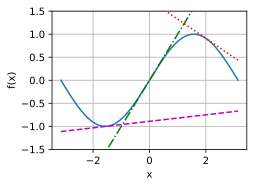

In [4]:
import numpy as onp
# Compute sin
xs = onp.arange(-onp.pi, onp.pi, 0.01)
plots = [onp.sin(xs)]

# Compute some linear approximations. Use d(sin(x)) / dx = cos(x)
for x0 in [-1.5, 0, 2]:
    plots.append(onp.sin(x0) + (xs - x0) * onp.cos(x0))

d2l.plot(xs, plots, 'x', 'f(x)', ylim=[-1.5, 1.5])

### The Gradient-Descent Step

So far we have *observed* $\epsilon$; now we get to *choose* it. In the small-change identity the equation the step $\epsilon$ is ours to pick, and we want to pick it so that $f$ goes *down*. The identity already predicts the effect of any step: a step $\epsilon$ changes the output by about $\epsilon\, f'(x)$. To make that change negative, point the step opposite the slope: take $\epsilon = -\eta\, f'(x)$ for a step size $\eta > 0$, and, *if the step is not too large*, the descent is guaranteed.

The qualification matters. The small-change identity by itself only describes the first-order *model*; turning "the model goes down" into "$f$ really goes down" needs control on how fast the slope can change over the step, which is exactly the curvature. The standard hypothesis is that $f'$ is **$L$-Lipschitz** near $x$, meaning $|f'(u) - f'(v)| \le L\,|u-v|$ for $u,v$ in a neighborhood, so the slope cannot swing by more than $L$ per unit of $x$. (If $f$ is twice differentiable this just says $|f''| \le L$ there.) Under that single assumption the first-order *guess* becomes a genuine *inequality*, the descent lemma of smooth optimization [@Nesterov.2018].

**Proposition (descent lemma).** *Suppose $f'$ is $L$-Lipschitz on a neighborhood of $x$. Then for every step size $\eta > 0$ small enough that the segment stays in that neighborhood,*

$$
f\bigl(x - \eta\, f'(x)\bigr) \;\le\; f(x) - \eta\left(1 - \tfrac{L\eta}{2}\right)[f'(x)]^2.
$$

*In particular $f$ strictly decreases whenever $0 < \eta < 2/L$ and $f'(x) \neq 0$, and the guaranteed decrease is largest at the step $\eta = 1/L$, where the bound reads $f(x - \tfrac1L f'(x)) \le f(x) - \tfrac{1}{2L}[f'(x)]^2$.*

**Proof.** Write the exact change in $f$ along the step as an integral of the slope, using the fundamental theorem of calculus (which we take on faith until that section), then add and subtract the slope at the base point:

$$
f(x+s) - f(x) = \int_0^1 f'(x + t s)\, s \, dt = f'(x)\, s + \int_0^1 \bigl(f'(x + t s) - f'(x)\bigr) s\, dt.
$$

Bounding the remaining integrand with the Lipschitz hypothesis, $|f'(x+ts) - f'(x)| \le L\,|ts| = Lt|s|$, and using $\int_0^1 t\, dt = \tfrac12$ gives $f(x+s) \le f(x) + f'(x)\,s + \tfrac{L}{2}s^2$. Now insert the descent step $s = -\eta\,f'(x)$:

$$
f\bigl(x - \eta\, f'(x)\bigr) \le f(x) - \eta\,[f'(x)]^2 + \tfrac{L}{2}\eta^2 [f'(x)]^2 = f(x) - \eta\left(1 - \tfrac{L\eta}{2}\right)[f'(x)]^2.
$$

The bracket $1 - L\eta/2$ is positive exactly for $\eta < 2/L$, and as a function of $\eta$ the whole coefficient $\eta(1 - L\eta/2)$ is maximized at $\eta = 1/L$. $\blacksquare$

the figure turns the proof into a picture. The inequality in its middle, $f(x+s) \le f(x) + f'(x)\,s + \tfrac{L}{2}s^2$, says the Lipschitz hypothesis erects a *quadratic ceiling* over the graph, touching it at the base point. Whatever $f$ does underneath, stepping to the ceiling's minimizer (which is exactly the gradient step with $\eta = 1/L$, at $s = -f'(x)/L$) lands where even the ceiling has dropped by $\tfrac{1}{2L}[f'(x)]^2$, so $f$, trapped below it, must have dropped at least as much. The guarantee is a worst-case floor: in the figure the function falls much further than the parabola promises.

![With an $L$-Lipschitz slope the function is trapped beneath the quadratic upper bound $f(x) + f'(x)s + \frac{L}{2}s^2$, which touches the graph at the base point. The gradient step with $\eta = 1/L$ lands exactly at the parabola's minimizer, where the ceiling, and hence $f$ beneath it, sits at least $\frac{1}{2L}f'(x)^2$ below the starting value. Here $f(x) = \sin(2x)$ with $L = 4$: the actual drop far exceeds the guaranteed one, which is the point, since the lemma is a worst-case floor.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-descent-lemma.svg)

The leading term $-\eta\,[f'(x)]^2$ is the first-order promise of the equation; the new $+\tfrac{L}{2}\eta^2[f'(x)]^2$ is the *curvature tax* the model ignored, and the lemma shows the tax stays strictly below the first-order gain as long as $\eta < 2/L$. The square is still the whole point: *whatever* the sign of the slope, moving against it lowers $f$, by an amount proportional to the slope *squared*, steepest where the function is steepest, vanishing only where $f'(x) = 0$. Iterating the step is **gradient descent**, the one-dimensional version of the loop that trains every network in this book,

$$
x_{t+1} = x_t - \eta\, f'(x_t),
$$

which is exactly the weight update $\mathbf{w} \leftarrow \mathbf{w} - \eta\,\nabla L(\mathbf{w})$ from the introduction, one coordinate at a time. the figure shows a single step: stand at $x$, follow the tangent downhill by $-\eta f'(x)$, and land lower on the curve.

![One gradient-descent step on a 1-D bowl. At $x$ the tangent line has slope $f'(x)$; the step $-\eta f'(x)$ moves opposite the slope and lands at $x - \eta f'(x)$, lower on the curve, with the drop equal to $\eta f'(x)^2$ to first order.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-gd-step.svg)

Two consequences follow. The descent stalls *exactly* at the **stationary condition** $f'(x) = 0$: the update stops moving and the equation predicts no further decrease, which is why $f'(x) = 0$ is the equation we solve to find candidate minima. And the descent lemma pins down what "too large a step" means: the guaranteed decrease holds only for $\eta < 2/L$, and at $\eta = 2/L$ the curvature tax exactly cancels the first-order gain. Push $\eta$ past $2/L$ and the bound flips sign: a single step can overshoot the minimum and *increase* $f$, the failure mode analyzed at length in that section. So the Lipschitz constant $L$ of the slope (the curvature, which the second derivative measures next) is precisely what sets how large $\eta$ may safely be.

We can see all of this on the simplest example, $f(x) = x^2$, whose slope is $f'(x) = 2x$. The gradient-descent step becomes

$$
x_{t+1} = x_t - \eta\,(2x_t) = (1 - 2\eta)\, x_t,
$$

a simple geometric recursion with closed form $x_t = (1-2\eta)^t x_0$. So the iterates converge to the minimum $x = 0$ exactly when $|1 - 2\eta| < 1$, i.e. for $0 < \eta < 1$. This is the descent lemma made exact: here $f'' \equiv 2$ so $L = 2$ and the safe range $\eta < 2/L = 1$ is precisely the convergence threshold. Within it, tiny $\eta$ creeps in monotonically, the optimal $\eta = 1/L = \tfrac12$ jumps to the minimum in one step, $\tfrac12 < \eta < 1$ overshoots and oscillates inward, $\eta = 1$ oscillates forever between $\pm x_0$, and $\eta > 1$ diverges. The next code cell runs the recursion for a sweep of step sizes, prints where each lands after ten steps, and plots the five trajectories $x_t$.

eta = 0.05 -> x_10 = +0.34868
eta = 0.50 -> x_10 = +0.00000
eta = 0.90 -> x_10 = +0.10737
eta = 1.00 -> x_10 = +1.00000
eta = 1.10 -> x_10 = +6.19174


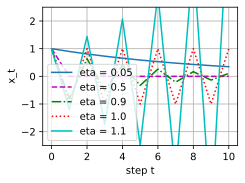

In [5]:
# Gradient descent on f(x) = x^2 from x0 = 1, for several step sizes
def gd(eta, steps=10, x0=1.0):
    xs = [x0]
    for _ in range(steps):
        xs.append(xs[-1] - eta * (2 * xs[-1]))  # x <- x - eta * f'(x)
    return xs

etas = [0.05, 0.5, 0.9, 1.0, 1.1]
trajectories = [gd(eta) for eta in etas]
for eta, xs in zip(etas, trajectories):
    print(f'eta = {eta:.2f} -> x_10 = {xs[-1]:+.5f}')
d2l.plot(list(range(11)), trajectories, 'step t', 'x_t', ylim=[-2.5, 2.5],
         legend=[f'eta = {eta}' for eta in etas],
         fmts=('-', 'm--', 'g-.', 'r:', 'c-'))

The printout and the picture tell the same story, one regime per curve: $\eta = 0.05$ creeps toward $0$ monotonically, $\eta = 0.5$ lands on it in a single step, $\eta = 0.9$ converges while zig-zagging across the minimum, $\eta = 1.0$ bounces between $\pm 1$ forever, and $\eta = 1.1$ oscillates with *growing* amplitude: it has left the plotting window within a handful of steps and reaches $|x_{10}| \approx 6.2$. The threshold $\eta = 2/L$ separating the last two regimes is exactly where the descent lemma's guarantee expires.

## Curvature and Taylor Series

The first derivative gave us the best *line* through a point. Its own derivative, the second derivative, measures how the slope itself bends, which is what distinguishes a minimum from a maximum and what limited the step size above. Pushing the idea to higher derivatives yields the *Taylor series*, the best polynomial model of a function.

### Higher-Order Derivatives and Curvature

The derivative $\frac{df}{dx}$ is itself a function, so nothing stops us from differentiating it again. Doing so yields the *second derivative*, $\frac{d^2f}{dx^2} = \frac{d}{dx}\!\left(\frac{df}{dx}\right)$: the derivative *operator* applied twice, **not** the square of $\frac{df}{dx}$. It is the rate of change of the rate of change: how the slope itself is changing. Repeating gives the $n$-th derivative,

$$
f^{(n)}(x) = \frac{d^{n}f}{dx^{n}} = \left(\frac{d}{dx}\right)^{n} f.
$$

What does the second derivative *tell* us? Its **sign** is the direction the curve bends, and read *locally* this is the classifier we need for optimization. Suppose $x_0$ is a stationary point, $f'(x_0) = 0$. Then the definition of the second derivative collapses to $f''(x_0) = \lim_{h \to 0} f'(x_0+h)/h$; if that limit is positive, the quotient $f'(x_0+h)/h$ is positive for all small $h \neq 0$, so $f'(x_0+h)$ shares the sign of $h$: just left of $x_0$ the slope is negative ($f$ falling), just right of $x_0$ it is positive ($f$ rising). The function dips and turns back up, so $x_0$ is a **local minimum**. Symmetrically, $f''(x_0) < 0$ makes the slope positive then negative, so $f$ rises and turns back down and $x_0$ is a **local maximum**. This is the **second-derivative test**, and it certifies *only the neighborhood* of $x_0$, not the whole function; the global picture, when $f$ is convex, is the subject of that section.

The three constant-curvature functions show what each sign *means*, even though most functions have a varying $f''$. A positive constant $f''$ keeps the slope increasing everywhere, so $f'$ runs from negative through zero to positive and the graph is a single upward bowl (the figure), exactly the bowl that gradient descent rolls into.

![A constant positive second derivative keeps the first derivative increasing, so the function curves upward; near a point where the slope crosses zero this is the local-minimum shape of the second-derivative test.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-pos-second.svg)

A negative constant $f''$ keeps the slope decreasing, running from positive through zero to negative: the upward dome of a maximum (the figure).

![A constant negative second derivative keeps the first derivative decreasing, so the function curves downward into the local-maximum shape.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-neg-second.svg)

And a zero $f''$ leaves the slope unchanged: $f$ rises or falls at a fixed rate and is a straight **line** with no curvature at all (the figure), the borderline the test cannot decide.

![A zero second derivative keeps the first derivative constant, so the function is a straight line: no curvature, and the borderline case where the second-derivative test is inconclusive.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-zero-second.svg)

In short, the *sign* of the second derivative at a stationary point decides minimum versus maximum: positive curves up into a min, negative curves down into a max, zero is undecided. (This is the one-dimensional shadow of the Hessian eigenvalue test for many variables in that section.)

### The Mean Value Theorem

We have been spending the derivative freely: a vanishing slope marks a candidate extremum, a negative slope means the function is falling. Both deductions read information about $f$ *itself* off its derivative at single points, and the one theorem that licenses every such reading is the **Mean Value Theorem**. Its statement is a picture (the figure): draw the secant chord joining the endpoints of the graph over $[a,b]$; somewhere inside, the tangent runs *parallel* to it. The average rate of change is achieved exactly, as an instantaneous rate, at some interior point.

![Over the interval from $a$ to $b$, the secant chord through the endpoints has slope equal to the average rate of change; the Mean Value Theorem says some interior point $\xi$ has a tangent of that same slope, parallel to the chord.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-mvt.svg)

**Proposition (Mean Value Theorem).** *If $f$ is continuous on $[a,b]$ and differentiable on $(a,b)$, then there is a point $\xi \in (a,b)$ with*

$$
f'(\xi) = \frac{f(b) - f(a)}{b - a}.
$$

**Proof.** First take the flat case $f(a) = f(b)$ (Rolle's theorem). We grant ourselves one fact from real analysis, the **extreme value theorem**: a continuous function on a closed interval attains a maximum and a minimum [@Rudin.1976]. If both occur at the endpoints then $f$ is constant and $f' \equiv 0$ inside; otherwise an extremum sits at some interior $\xi$, say a maximum, so $f(\xi + \epsilon) - f(\xi) \le 0$ on both sides. The difference quotient is then $\le 0$ for $\epsilon > 0$ and $\ge 0$ for $\epsilon < 0$, and since $f$ is differentiable at $\xi$ both one-sided limits equal $f'(\xi)$; a number that is both $\le 0$ and $\ge 0$ is zero, so $f'(\xi) = 0$ (a minimum is symmetric). For the general case, subtract off the chord: the tilted function $g(x) = f(x) - \frac{f(b)-f(a)}{b-a}(x - a)$ has $g(a) = g(b) = f(a)$, so the flat case gives a $\xi$ with $g'(\xi) = 0$, which is exactly the equation. $\blacksquare$

Two corollaries are the facts we already used. If $f' > 0$ throughout an interval then for any $x_1 < x_2$ in it, the equation gives $f(x_2) - f(x_1) = f'(\xi)(x_2 - x_1) > 0$ for some $\xi$ between them, so $f$ is **increasing**: a positive slope really does mean the function climbs, and the sign of $f'$ governs monotonicity. And if $f$ has a *constant* sign of $f'$ on each side of a stationary point, the theorem turns that into the rise-and-fall behaviour the second-derivative test read off. The Mean Value Theorem is the formal bridge from *the derivative at a point* to *the behaviour of the function on an interval*.

### The Best Quadratic, and the Taylor Idea

The first derivative built the best line; the second lets us build the best *parabola*. Consider a generic quadratic $g(x) = ax^2 + bx + c$, for which

$$
\begin{aligned}
\frac{dg}{dx}(x) & = 2ax + b \\
\frac{d^2g}{dx^2}(x) & = 2a.
\end{aligned}
$$

A quadratic has three free coefficients, so we can match three pieces of information about $f$ at a base point $x_0$: its value, slope, and curvature. Demanding $g(x_0) = f(x_0)$, $g'(x_0) = f'(x_0)$, and $g''(x_0) = f''(x_0)$ pins down $a$, $b$, $c$ uniquely and produces the best local *quadratic* model, just as the tangent was the best local *line*. For $f(x) = \sin(x)$ at base point $x_0$, using $\frac{d}{dx}\sin(x) = \cos(x)$ and $\frac{d^2}{dx^2}\sin(x) = -\sin(x)$, the model reads

$$
g(x) = \sin(x_0) + \cos(x_0)\,(x - x_0) - \tfrac{1}{2}\sin(x_0)\,(x-x_0)^2,
$$

a parabola that hugs the curve over a visibly wider window than the tangent lines we plotted above, because it captures curvature as well as slope; the figure draws all three together. We will make the "wider window" claim quantitative, and verify it in code, once the Taylor remainder is on the table. But first, the quadratic model changes how we optimize.

![The sine curve with its two local models at $x_0$: the tangent line matches value and slope, while the best parabola also matches curvature and stays close over a wider window before peeling away.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-best-parabola.svg)

### Newton's Method

The best quadratic is a better *optimizer*. Gradient descent treats the local model as a line, and a line has no minimum, so we had to be told how far to walk down it by the step size $\eta$. The quadratic model has a minimum of its own, and we can simply jump there. Writing the model at the current iterate $x_t$ (with $f''(x_t) > 0$ so it opens upward),

$$
q(x) = f(x_t) + f'(x_t)\,(x - x_t) + \tfrac{1}{2}f''(x_t)\,(x - x_t)^2,
$$

and solving $q'(x) = f'(x_t) + f''(x_t)(x - x_t) = 0$ for $x$ gives the update of **Newton's method**:

$$
x_{t+1} = x_t - \frac{f'(x_t)}{f''(x_t)}.
$$

Read against the gradient-descent loop the equation, this is the same step with the hand-tuned $\eta$ replaced by the *curvature-adapted* step size $1/f''(x_t)$: sharp curvature prescribes caution, gentle curvature boldness. On $f(x) = x^2$ it sets $\eta = 1/f'' = \tfrac12$, exactly the one-shot optimal step we found by hand. Its speed in general is a theorem we state without proof: if $f''$ is Lipschitz near a local minimizer $x^\star$ with $f''(x^\star) > 0$, and the iteration starts close enough to $x^\star$, then it converges *quadratically*, roughly doubling the number of correct digits per step [@Nocedal.Wright.2006]. The price is the curvature itself: where $f''(x_t) \le 0$ the model's "minimum" is a maximum or does not exist and the raw step must be safeguarded, and in $n$ dimensions $f''$ becomes the Hessian matrix, so each step requires solving an $n \times n$ linear system. How this trade plays out at deep-learning scale, and why first-order methods win there anyway, is taken up in that section.

The quadratic convergence is easy to watch. Take $f(x) = \tfrac14 x^4 - x$, whose stationarity condition $f'(x) = x^3 - 1 = 0$ has the root $x^* = 1$; the next cell iterates the equation from $x_0 = 2$ and prints the error at each step.

In [6]:
# Newton's method on f(x) = x^4/4 - x: solve f'(x) = x^3 - 1 = 0, root x* = 1
x = 2.0
for t in range(6):
    print(f't = {t}: x = {x:.12f}, error = {abs(x - 1):.1e}')
    x = x - (x**3 - 1) / (3 * x**2)  # x - f'(x) / f''(x)

t = 0: x = 2.000000000000, error = 1.0e+00
t = 1: x = 1.416666666667, error = 4.2e-01
t = 2: x = 1.110534409842, error = 1.1e-01
t = 3: x = 1.010636768405, error = 1.1e-02
t = 4: x = 1.000111557304, error = 1.1e-04
t = 5: x = 1.000000012443, error = 1.2e-08


Read the error column's exponents: after a couple of settling-in steps they go $10^{-2} \to 10^{-4} \to 10^{-8}$: each step roughly *squares* the previous error, doubling the number of correct digits. Contrast the $\eta$-sweep above, where gradient descent shrinks the error by the same fixed factor $|1 - 2\eta|$ every step: geometric convergence gains a fixed number of digits per step, Newton doubles them. Matching yet *more* derivatives with higher-degree polynomials is the Taylor series, to which we now turn.

### Taylor Series

The *Taylor series* generalizes the tangent and the best parabola: given the value and first $n$ derivatives of $f$ at a base point $x_0$, find the degree-$n$ polynomial that matches all of them. The quadratic case, rewritten in displacement from $x_0$, is

$$
f(x) \approx f(x_0) + \frac{df}{dx}(x_0)(x-x_0) + \frac{1}{2}\frac{d^2f}{dx^2}(x_0)(x-x_0)^{2}.
$$

The factor $\tfrac12$ is bookkeeping: differentiating $(x-x_0)^2$ twice produces a $2$, and dividing by $2$ leaves the coefficient equal to $f''(x_0)$, while all lower terms differentiate to zero at $x_0$. The same accounting at degree $3$ produces a $3! = 6$,

$$
f(x) \approx f(x_0) + \frac{df}{dx}(x_0)(x-x_0) + \frac{\frac{d^2f}{dx^2}(x_0)}{2}(x-x_0)^{2} + \frac{\frac{d^3f}{dx^3}(x_0)}{6}(x-x_0)^3,
$$

and in general the $i$-th term carries an $i!$, giving the degree-$n$ **Taylor polynomial**

$$
P_n(x) = \sum_{i = 0}^{n} \frac{f^{(i)}(x_0)}{i!}(x-x_0)^{i},
$$

the best degree-$n$ polynomial approximation to $f$ near $x_0$.

How good is it? The machinery of the Mean Value Theorem answers exactly.

**Proposition (Lagrange remainder).** *If $f$ is $(n+1)$-times differentiable on an open interval containing $x_0$ and $x$, then*

$$
f(x) = P_n(x) + R_n(x), \qquad R_n(x) = \frac{f^{(n+1)}(\xi)}{(n+1)!}\,(x - x_0)^{n+1},
$$

*for some $\xi$ strictly between $x_0$ and $x$. The case $n = 0$ is the Mean Value Theorem the equation itself, $f(x) = f(x_0) + f'(\xi)(x - x_0)$.*

**Proof.** Fix $x \neq x_0$ and make the *base point* the variable: for $t$ between $x_0$ and $x$, let

$$
G(t) = f(x) - \sum_{k=0}^{n} \frac{f^{(k)}(t)}{k!}\,(x-t)^k - M\,\frac{(x-t)^{n+1}}{(n+1)!},
$$

where the constant $M$ is chosen so that $G(x_0) = 0$. Since $G(x_0) = f(x) - P_n(x) - M\,(x-x_0)^{n+1}/(n+1)!$, the claim the equation is exactly that this $M$ equals $f^{(n+1)}(\xi)$ for some interior $\xi$. We also have $G(x) = 0$: at $t = x$ every power of $(x - t)$ vanishes and the $k = 0$ term leaves $f(x) - f(x)$. Because $f$ is $(n+1)$-times differentiable, $G$ is differentiable between $x_0$ and $x$, so Rolle's theorem (the flat case established in that section) gives a $\xi$ strictly between $x_0$ and $x$ with $G'(\xi) = 0$. Now differentiate $G$ in $t$. By the product rule, the $k$-th summand contributes $\frac{f^{(k+1)}(t)}{k!}(x-t)^k - \frac{f^{(k)}(t)}{(k-1)!}(x-t)^{k-1}$ for $k \ge 1$, and the $k = 0$ term contributes $f'(t)$; the second half of each summand cancels the first half of the one before it, so the sum telescopes to its last surviving piece, $\frac{f^{(n+1)}(t)}{n!}(x-t)^n$. Hence

$$
G'(t) = -\frac{f^{(n+1)}(t)}{n!}\,(x-t)^n + M\,\frac{(x-t)^n}{n!},
$$

and setting $t = \xi$, where $(x - \xi)^n \neq 0$, forces $M = f^{(n+1)}(\xi)$. $\blacksquare$

The remainder is one term *past* the polynomial, evaluated at an unknown interior $\xi$ instead of at $x_0$. It makes "the approximation improves near $x_0$" quantitative: the error shrinks like $|x - x_0|^{n+1}$, so each extra matched derivative adds another power of closeness. The case $n = 1$ is the curvature tax we already met ($R_1 = \tfrac12 f''(\xi)(x-x_0)^2$ is exactly the $\tfrac{L}{2}\eta^2$ term bounded in the descent lemma the equation), and the same quadratic remainder is what Newton's method (that section) drives to zero by stepping to the minimum of $P_2$ rather than $P_1$.

That rate is checkable, and checking it is the promised quantitative version of the "wider window" claim from the figure. The next cell takes $f(x) = e^x$ at $x_0 = 0$, measures the worst error of $P_n$ over a window $|x| \le h$, and then halves the window: if the error scales like $h^{n+1}$, halving $h$ should divide it by $2^{n+1}$, i.e. by $4$ for the tangent line, $8$ for the best quadratic, $16$ for the cubic.

In [7]:
# Max error of the degree-n Taylor polynomial of e^x on the window |x| <= h.
# Lagrange predicts error ~ h^(n+1): halving h should divide it by 2^(n+1)
def taylor_error(n, h, m=1000):
    coeffs = [1.0, 1.0, 1 / 2, 1 / 6]  # 1/k! for k = 0, ..., 3
    err = 0.0
    for i in range(-m, m + 1):
        x = h * i / m
        err = max(err, abs(math.exp(x) - sum(coeffs[k] * x**k
                                             for k in range(n + 1))))
    return err

for n in [1, 2, 3]:
    e1, e2 = taylor_error(n, 0.2), taylor_error(n, 0.1)
    print(f'n = {n}: max error {e1:.1e} (h = 0.2) vs {e2:.1e} (h = 0.1), '
          f'ratio = {e1 / e2:.1f}, prediction 2^{n + 1} = {2**(n + 1)}')

n = 1: max error 2.1e-02 (h = 0.2) vs 5.2e-03 (h = 0.1), ratio = 4.1, prediction 2^2 = 4
n = 2: max error 1.4e-03 (h = 0.2) vs 1.7e-04 (h = 0.1), ratio = 8.2, prediction 2^3 = 8
n = 3: max error 6.9e-05 (h = 0.2) vs 4.3e-06 (h = 0.1), ratio = 16.3, prediction 2^4 = 16


The measured ratios $4.1$, $8.2$, $16.3$ sit right on the predicted $4$, $8$, $16$: the tangent line's error falls fourfold per halving while the cubic's falls sixteenfold, the wider-window effect measured. (The slight overshoot is also predicted: the remainder's $e^{\xi}$ factor is a touch larger over the wider window.)

Letting $n \to \infty$ gives the full *Taylor series*. Call $f$ **real analytic** at $x_0$ if its Taylor series there converges on a neighborhood of $x_0$ *and* its sum equals $f$ throughout that neighborhood. For such functions, $\cos(x)$ and $e^{x}$ among them, the infinitely many terms reproduce the function exactly:

$$
f(x) = \sum_{n = 0}^\infty \frac{f^{(n)}(x_0)}{n!}(x-x_0)^{n}.
$$

Two separate things can go wrong, which is why the definition demands both. The series can fail to converge away from $x_0$; and even where it converges, its sum can differ from $f$, since convergence of the series is not the same as convergence *to $f$*. Being infinitely differentiable (smooth) guarantees neither. The classic counterexample is $f(x) = e^{-1/x^2}$ (with $f(0) = 0$), which is smooth everywhere yet has $f^{(n)}(0) = 0$ for every $n$; its Taylor series at $x_0 = 0$ is identically zero: it converges on the *whole line*, but to the zero function, reproducing $f$ only at $x = 0$ itself (the figure). So an infinite radius of convergence guarantees nothing about agreement with $f$. In practice we mostly use the *finite* truncations $P_n$, whose error the equation we can bound directly, and which sharpen the closer $x$ is to $x_0$.

![The smooth function $f(x) = e^{-1/x^2}$ has every derivative equal to zero at the origin, so its Taylor series there is identically zero. The series converges everywhere yet agrees with $f$ only at $x = 0$: smooth does not imply analytic.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-smooth-not-analytic.svg)

Take $f(x) = e^{x}$ as an example. Since $e^{x}$ is its own derivative, we know that $f^{(n)}(x) = e^{x}$. Therefore, $e^{x}$ can be reconstructed by taking the Taylor series at $x_0 = 0$, i.e.,

$$
e^{x} = \sum_{n = 0}^\infty \frac{x^{n}}{n!} = 1 + x + \frac{x^2}{2} + \frac{x^3}{6} + \cdots.
$$

Plotting $P_1$, $P_2$, and $P_5$ against $e^x$ shows each higher degree tracking the curve farther from the base point.

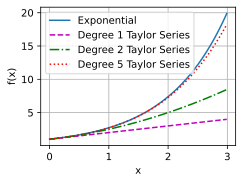

In [8]:
# This calculation is backend-neutral, so one NumPy cell serves every tab.
xs = onp.arange(0, 3, 0.01)
ys = onp.exp(xs)
P1 = 1 + xs
P2 = 1 + xs + xs**2 / 2
P5 = 1 + xs + xs**2 / 2 + xs**3 / 6 + xs**4 / 24 + xs**5 / 120

d2l.plot(xs, [ys, P1, P2, P5], 'x', 'f(x)', legend=[
    "Exponential", "Degree 1 Taylor Series", "Degree 2 Taylor Series",
    "Degree 5 Taylor Series"])

Taylor series matter here in two ways. *Theoretically*, replacing an unwieldy function by its low-degree polynomial makes it tractable: the first-order term is what gave us gradient descent, the second-order term is the curvature behind Newton's method and step-size limits. *Numerically*, the same local-polynomial idea underlies elementary-function libraries, but production implementations do more than truncate the Taylor series at the input: they first reduce the argument to a small interval and then evaluate a carefully chosen polynomial or rational approximation with controlled error.

## When the Tangent Fails

Everything so far rested on the "zoom in and see a line" picture: a smooth function looks linear up close, so the limit the equation exists. But the activation that built modern deep learning, $\mathrm{ReLU}(x) = \max(0, x)$, has a *corner* at the origin, and so does $|x|$. At a corner the microscope never settles on one line, and the ordinary derivative is undefined. This section says exactly what goes wrong, what to use instead, and why stochastic gradient descent (gradient descent driven by gradients estimated on random minibatches of data, that section) is unaffected in practice.

### One-Sided Derivatives

The trouble is visible directly in the difference quotient the equation. For $f(x) = |x|$ at $x = 0$,

$$
\frac{|0+\epsilon| - |0|}{\epsilon} = \frac{|\epsilon|}{\epsilon} =
\begin{cases} +1 & \epsilon > 0, \\ -1 & \epsilon < 0. \end{cases}
$$

The two sides give different limits, so no single number is *the* slope: approaching from the right the function rises with slope $+1$, from the left it falls with slope $-1$. These are the **one-sided derivatives** $f'_+(0) = +1$ and $f'_-(0) = -1$. The ordinary two-sided derivative exists only when they agree. For $\mathrm{ReLU}$ at $0$ the same computation gives $f'_-(0) = 0$ (flat on the left) and $f'_+(0) = 1$ (slope $1$ on the right). Note there is no limit to take: for $|x|$ at $0$ the two quotients are the *constants* $\pm 1$, the same at every $\epsilon$, so the next cell prints them once. It then asks the question this section turns on: what does autograd return at the corner, where no true derivative exists?

In [9]:
# One-sided difference quotients of |x| at 0: constants, no limit needed
epsilon = 1e-4
print(f'right quotient: {(abs(epsilon) - abs(0)) / epsilon:+.1f}, '
      f'left quotient: {(abs(-epsilon) - abs(0)) / -epsilon:+.1f}')

# What autograd returns at the corner, where no derivative exists
for name, fn in [('d|x|/dx', torch.abs), ("ReLU'", torch.relu)]:
    x = torch.tensor(0.0, requires_grad=True)
    fn(x).backward()
    print(f"{name} at 0: autograd returns {x.grad.item():.1f}")

right quotient: +1.0, left quotient: -1.0
d|x|/dx at 0: autograd returns 0.0
ReLU' at 0: autograd returns 0.0


Autograd does not refuse. For both $\frac{d}{dx}|x|$ and $\mathrm{ReLU}'$ at $0$ it returns the fixed value $0$: one particular slope, chosen by convention, from the set of candidates we now define.

### Subgradients and Optimality

The fix is to stop insisting on a *single* tangent and allow *all* the lines that stay below the graph. A number $g$ is a **subgradient** of a convex function $f$ (one whose every chord lies on or above its graph) at $x$ if

$$
f(y) \ge f(x) + g\,(y - x) \quad \textrm{for all } y,
$$

i.e. the line through $(x, f(x))$ with slope $g$ is a global underestimate of $f$. The set of all such slopes is the **subdifferential** $\partial f(x)$ [@Rockafellar.1970]. Away from a corner it is the single ordinary slope; at a corner it is the whole interval *between* the one-sided derivatives, the "fan" of supporting lines shown in the figure:

$$
\partial |x|(0) = [-1, 1], \qquad \partial\, \mathrm{ReLU}(0) = [0, 1].
$$

Off the corner each function is differentiable and the subdifferential collapses to the single ordinary slope; at the corner, the $0$ that autograd returned above is one element of each set.

![Two corners and their subdifferentials: the fan of supporting lines through the origin of $|x|$ (left) and of $\mathrm{ReLU}$ (right), with slopes running over $\partial|x|(0)$ and $\partial\,\mathrm{ReLU}(0)$ respectively. Off each corner there is a single tangent and the subdifferential collapses to the ordinary derivative.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-cal-relu-corner.svg)

The subgradient restores the optimality test. For differentiable $f$ a minimum requires $f'(x) = 0$; the subgradient version is the inclusion

$$
0 \in \partial f(x).
$$

This is no harder to prove than its smooth cousin: taking $g = 0$ in the equation reads $f(y) \ge f(x)$ for all $y$, which is precisely the statement that $x$ is a global minimum. For $|x|$ at $0$ we have $0 \in [-1,1] = \partial|x|(0)$, correctly certifying the origin as the minimum even though no derivative exists there, exactly the case the smooth test $f'(x)=0$ cannot reach.

### Why SGD Shrugs

Corners do not, in practice, break training. To see why, look at what autograd actually does at them. One clarification first, so the convexity above is not over-read: a deep network's loss surface is wildly *non*-convex, while the subdifferential the equation is a *convex*-function notion. The kinks in a network come from convex building blocks ($|x|$, $\mathrm{ReLU}$, the hinge loss $\max(0, 1-x)$), and what autograd does at each kink is simple: it returns *one fixed element* of that piece's subdifferential (the deep-learning libraries' convention is $\mathrm{ReLU}'(0) = 0$, as the cell above showed) and lets the chain rule propagate that choice through the surrounding, nonconvex composition.

Two caveats apply. First, even for a convex function a subgradient step need not be a *descent* step: at the minimum of $|x|$ the perfectly valid subgradient $g = \tfrac12 \in \partial|x|(0)$ sends the update to $x = -\eta/2$ and *increases* the function; the subgradient method of convex optimization converges by shrinking its step sizes, not by descending monotonically [@Nesterov.2018]. Second, the chain rule carries no warranty at kinks: chaining per-kink choices can produce a number that is not a subgradient of the composite *at all*. The simplest failure is the identity in disguise

$$
g(x) = \mathrm{ReLU}(x) - \mathrm{ReLU}(-x) = x \quad \textrm{for all } x,
$$

whose only correct slope at $0$ is $1$. The chain rule gives $g'(x) = \mathrm{ReLU}'(x) + \mathrm{ReLU}'(-x)$, which is indeed $1$ everywhere *except* at the kink, where the fixed convention makes it $0 + 0 = 0$. The next cell runs exactly this computation.

In [10]:
# g(x) = relu(x) - relu(-x) is the identity, so the true slope at 0 is 1
x = torch.tensor(0.0, requires_grad=True)
g = torch.relu(x) - torch.relu(-x)
g.backward()
print(f"autograd: g'(0) = {x.grad.item():.1f}  (true slope: 1.0)")

autograd: g'(0) = 0.0  (true slope: 1.0)


Autograd reports slope $0$ for a function that *is* the identity: the per-kink convention $\mathrm{ReLU}'(0) = 0$, chained, produces a number that is not a subgradient of $g$ at $0$ at all. What automatic differentiation computes at nonsmooth points is, in general, an element of a *conservative field* [@Bolte.Pauwels.2021], a relaxed gradient notion that agrees with the true derivative everywhere outside a *measure-zero* set, one so small it can be covered by intervals of arbitrarily small total length (that section makes such size-zero statements precise). That a Lipschitz function even *has* a derivative outside a measure-zero set is **Rademacher's theorem** [@Rademacher.1919]. Under the definability/path-differentiability assumptions studied by
@Bolte.Pauwels.2021, together with bounded iterates and the usual
stochastic-approximation conditions on steps and gradient noise, SGD driven by
such a conservative field converges to an appropriate stationary set almost
surely. This is a conditional theorem, not a guarantee for every nonsmooth
program.

Why does training tolerate the occasional bad chained value? The usual picture is that a network's kinks (the points where some $\mathrm{ReLU}$ input is exactly zero) form a measure-zero set, and a randomly drawn point lands in a measure-zero set with probability zero, provided the draw comes from a distribution with a density (an *absolutely continuous* one). Take this as a heuristic picture rather than a theorem: we have not proved that the kink set of a whole network is measure zero, and in floating-point arithmetic the argument fails outright, since the floats are a countable set on which every representable value, exact zeros included, carries positive probability. The rigorous backstop is the conservative-field convergence result quoted above. The convex-analysis machinery is developed further in that section; the lesson here is that the local-linear program survives at corners because almost every step of stochastic training differentiates a locally smooth function, and the conservative-field theory covers the steps that do land on a kink.

## Summary

* The derivative is the *local linear model* of a function: $f(x+\epsilon) \approx f(x) + \epsilon f'(x)$. It is the slope of the line a smooth curve flattens onto when we zoom in, and the limit of difference quotients.
* The derivatives of elementary functions, combined with the sum, product, and chain rules, differentiate any expression mechanically. Each rule is the small-change identity expanded to first order; the chain rule run in reverse over a network is backpropagation.
* Choosing the step $\epsilon = -\eta f'(x)$ in the local model predicts a decrease of $\eta[f'(x)]^2$. When the slope is $L$-Lipschitz the *descent lemma* turns this into a genuine guarantee $f(x - \eta f'(x)) \le f(x) - \eta(1 - L\eta/2)[f'(x)]^2$, a strict drop for $0 < \eta < 2/L$ (best at $\eta = 1/L$). Descent stalls at the stationary points $f'(x) = 0$, and a step past $2/L$ can *increase* $f$ when curvature overwhelms the first-order gain.
* The second derivative is curvature: its sign decides minimum vs. maximum, and Taylor series extend the line and parabola to the best polynomial model of any order.
* At corners like $\mathrm{ReLU}(0)$ the derivative is undefined, but the *subdifferential* supplies a set of valid slopes ($\partial|x|(0) = [-1,1]$) and optimality becomes $0 \in \partial f(x)$. Autograd returns one fixed element per kink ($\mathrm{ReLU}'(0) = 0$); chained through a composition that value can fail to be a subgradient at the kinks themselves. Conservative-field theory supplies convergence results under additional structural, boundedness, step-size, and noise assumptions.

## Exercises

1. Compute the derivative of $x^3 - 4x + 1$, and of $\log\!\left(\frac{1}{x}\right)$ for $x > 0$.
2. Derive the quotient rule from the product and chain rules by writing $\frac{g(x)}{h(x)} = g(x)\cdot\left(h(x)\right)^{-1}$ and using the power rule with $n = -1$ for the outer function. Check your result on $\tan(x) = \frac{\sin(x)}{\cos(x)}$: you should find $\frac{d}{dx}\tan(x) = \frac{1}{\cos^2(x)}$.
3. True or false: if $f'(x) = 0$ then $f$ has a maximum or a minimum at $x$. If false, give a counterexample and the test that distinguishes the cases.
4. Find the minimum of $f(x) = x\log(x)$ for $x \ge 0$ (take the limiting value $f(0) = 0$).
5. The first-order model predicts $f(x - \eta f'(x)) \approx f(x) - \eta[f'(x)]^2$. Starting from the small-change identity, derive this prediction and name the term it discards. Then extend the descent lemma to the vector case: for $f: \mathbb{R}^n \to \mathbb{R}$ with an $L$-Lipschitz gradient ($\|\nabla f(\mathbf{u}) - \nabla f(\mathbf{v})\| \le L\|\mathbf{u} - \mathbf{v}\|$), show that $f(\mathbf{x} - \eta\nabla f(\mathbf{x})) \le f(\mathbf{x}) - \eta\left(1 - \tfrac{L\eta}{2}\right)\|\nabla f(\mathbf{x})\|^2$. (*Hint:* repeat the proof of the equation along the segment $\mathbf{x} + t\mathbf{s}$ with $\mathbf{s} = -\eta\nabla f(\mathbf{x})$, bounding the integral with the Cauchy--Schwarz inequality.)
6. For $f(x) = x^2$, find *all* step sizes $\eta$ for which gradient descent from $x_0 \neq 0$ converges to the minimum, and the one $\eta$ that reaches it in a single step. (*Hint:* use $x_{t+1} = (1-2\eta)x_t$.)
7. Give a function $f$ and a step size $\eta$ for which a single gradient-descent step *increases* $f$, and explain the failure: which hypothesis of the descent lemma the equation is violated, or is $\eta$ simply past $2/L$? (*Hint:* $f(x) = x^2$ with $\eta > 1$ already does it.)
8. Relate the one-dimensional update $x \leftarrow x - \eta f'(x)$ to the vector update $\mathbf{w} \leftarrow \mathbf{w} - \eta\nabla L(\mathbf{w})$ from the introduction.
9. Compute the subdifferentials $\partial\,\mathrm{ReLU}(0)$ and $\partial|x|(0)$. Which of $\{0,\, 0.5,\, 1\}$ are valid subgradients of $\mathrm{ReLU}$ at $0$? Sketch the subdifferential of the hinge loss $\max(0, 1 - x)$.
10. Use the degree-$5$ Taylor polynomial of $e^x$ at $x_0 = 0$ to estimate $e$, and compare with the true value.

[Discussions](https://d2l.discourse.group/t/1088)